# **Toxic Comment Classifier**
---


In [1]:
from pathlib import Path
import json
import random
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf



In [2]:
from IPython.display import IFrame, display
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'Jigsaw_Dataset' / 'train.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


DATA_PATH = PROJECT_ROOT / 'Jigsaw_Dataset' / 'train.csv'
MODEL_PATH = PROJECT_ROOT / 'models' / 'toxic_bilstm.keras'
THRESHOLDS_PATH = PROJECT_ROOT / 'models' / 'label_thresholds.json'
REPORTS_PATH = PROJECT_ROOT / 'reports'
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


SAMPLE_SIZE = None      # None for full dataset, or an integer for a sample size
TEST_SIZE = 0.20
MAX_TOKENS = 50_000     
SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64
BATCH_SIZE = 128
EPOCHS = 5
GLOBAL_THRESHOLD = 0.50

print('Project root:', PROJECT_ROOT.resolve())
print('TensorFlow version:', tf.__version__)


Project root: C:\Users\User\Desktop\IRFAN\Toxic Comment Classifier
TensorFlow version: 2.21.0


## Loading dataset

In [4]:
df = pd.read_csv(DATA_PATH)

required_columns = {'id', 'comment_text', *LABELS}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

print(f'Complete dataset: {len(df):,} rows and {df.shape[1]} columns')
display(df.head())

Complete dataset: 159,571 rows and 8 columns


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
df.tail(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


## DATA Quality

In [7]:
quality_summary = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique(),
})
display(quality_summary)
print('Duplicate comments:', df['comment_text'].duplicated().sum())

,data_type,missing_values,unique_values
id,str,0,159571
comment_text,str,0,159571
toxic,int64,0,2
severe_toxic,int64,0,2
obscene,int64,0,2
threat,int64,0,2
insult,int64,0,2
identity_hate,int64,0,2


Duplicate comments: 0


##  Preprocessing

The preprocessing function normalizes URLs, user mentions, whitespace, and control characters. Lowercasing and punctuation removal are subsequently performed by the Keras `TextVectorization` layer.

In [8]:
def clean_text(text):
    # Handle missing values
    text = "" if pd.isna(text) else str(text)

    # Convert to lowercase
    text = text.lower()

    # Replace URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

    # Replace email addresses
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)

    # Replace usernames
    text = re.sub(r'@[A-Za-z0-9_]+', ' USER ', text)

    # Replace numbers
    text = re.sub(r'\d+', ' NUMBER ', text)

    # Expand common contractions
    contractions = {
        "can't": "cannot",
        "won't": "will not",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'m": " am",
        "'s": " is"
    }

    for key, value in contractions.items():
        text = text.replace(key, value)

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove punctuation (keep words)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_comment'] = df['comment_text'].map(clean_text)
df['comment_length'] = df['clean_comment'].str.len()
df['word_count'] = df['clean_comment'].str.split().str.len()
df['is_toxic'] = df[LABELS].max(axis=1)

display(df[['comment_text', 'clean_comment', 'comment_length', 'word_count']].head())

,comment_text,clean_comment,comment_length,word_count
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...,279,50
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...,117,20
2,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...,231,44
3,"""\nMore\nI can't make any real suggestions on ...",more i cannot make any real suggestions on imp...,603,115
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...,64,14


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   id              159571 non-null  str  
 1   comment_text    159571 non-null  str  
 2   toxic           159571 non-null  int64
 3   severe_toxic    159571 non-null  int64
 4   obscene         159571 non-null  int64
 5   threat          159571 non-null  int64
 6   insult          159571 non-null  int64
 7   identity_hate   159571 non-null  int64
 8   clean_comment   159571 non-null  str  
 9   comment_length  159571 non-null  int64
 10  word_count      159571 non-null  int64
 11  is_toxic        159571 non-null  int64
dtypes: int64(9), str(3)
memory usage: 14.6 MB


In [10]:
quality_summary = pd.DataFrame({
    'data_type': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique(),
})
display(quality_summary)
print('Duplicate comments:', df['comment_text'].duplicated().sum())

,data_type,missing_values,unique_values
id,str,0,159571
comment_text,str,0,159571
toxic,int64,0,2
severe_toxic,int64,0,2
obscene,int64,0,2
threat,int64,0,2
insult,int64,0,2
identity_hate,int64,0,2
clean_comment,str,0,158382
comment_length,int64,0,3999


Duplicate comments: 0


## Exploratory data analysis

In [11]:
label_summary = pd.DataFrame({
    'positive_comments': df[LABELS].sum(),
    'percentage': df[LABELS].mean().mul(100),
}).sort_values('positive_comments', ascending=False)

print(f'Comments with at least one toxic label: {df["is_toxic"].sum():,} '
      f'({df["is_toxic"].mean():.2%})')
display(label_summary.style.format({'percentage': '{:.2f}%'}))
label_summary.to_csv(REPORTS_PATH / 'label_summary.csv')

Comments with at least one toxic label: 16,225 (10.17%)


,positive_comments,percentage
toxic,15294,9.58%
obscene,8449,5.29%
insult,7877,4.94%
severe_toxic,1595,1.00%
identity_hate,1405,0.88%
threat,478,0.30%


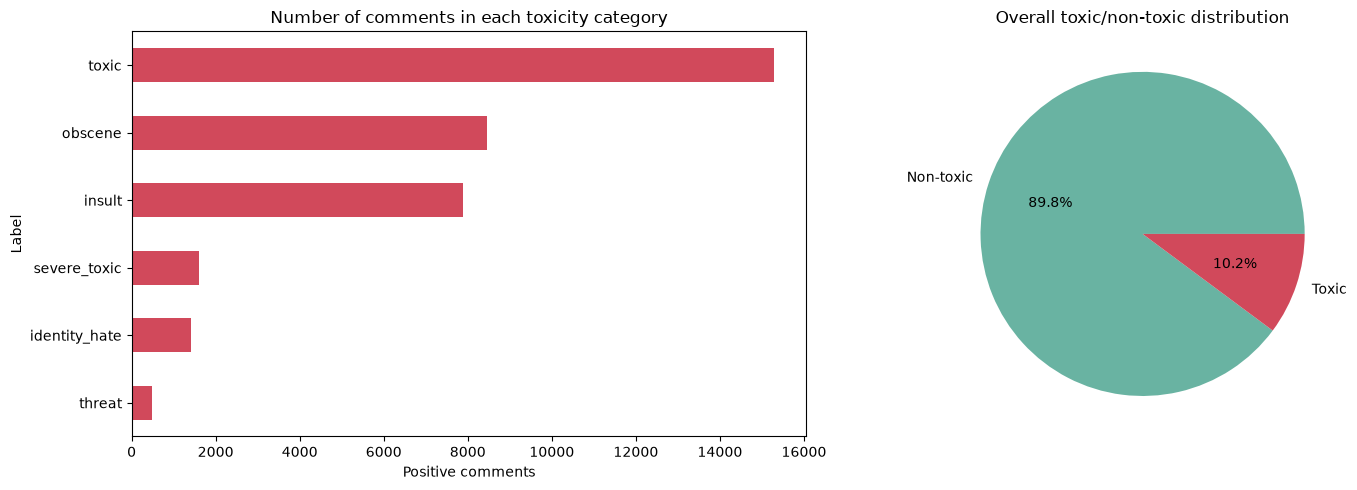

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))

label_summary.sort_values('positive_comments')['positive_comments'].plot(
    kind='barh', ax=axes[0], color='#d1495b'
)
axes[0].set_title('Number of comments in each toxicity category')
axes[0].set_xlabel('Positive comments')
axes[0].set_ylabel('Label')

df['is_toxic'].value_counts().sort_index().plot(
    kind='pie', labels=['Non-toxic', 'Toxic'], autopct='%1.1f%%',
    colors=['#69b3a2', '#d1495b'], ax=axes[1]
)
axes[1].set_title('Overall toxic/non-toxic distribution')
axes[1].set_ylabel('')

figure.tight_layout()
figure.savefig(REPORTS_PATH / 'label_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

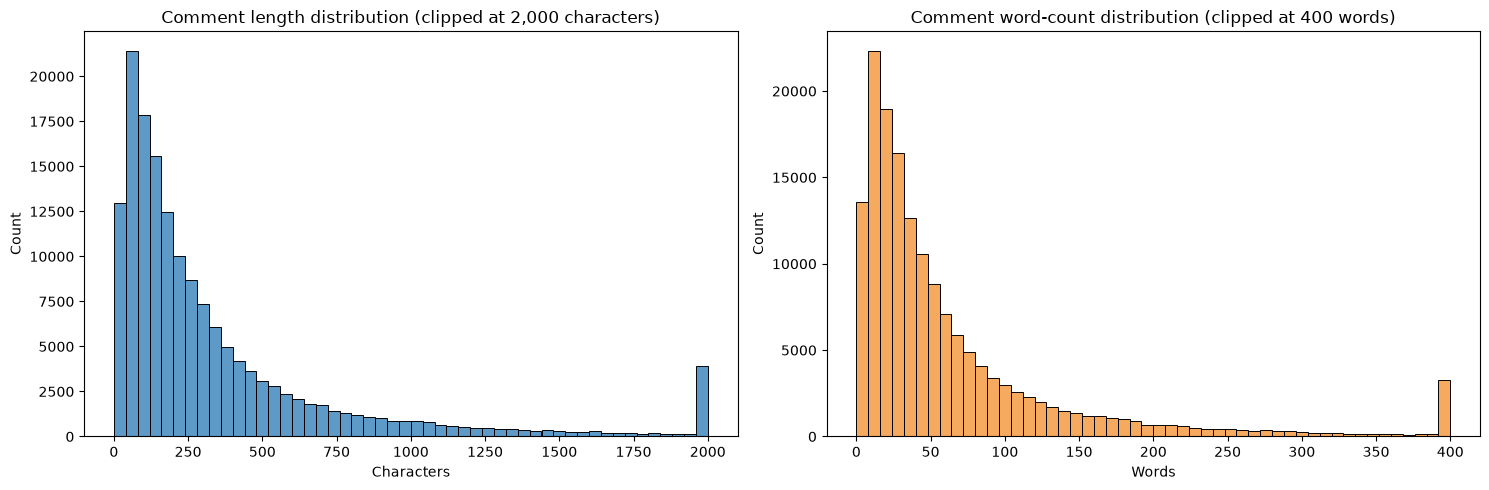

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['comment_length'].clip(upper=2000), bins=50, ax=axes[0], color='#2878b5')
axes[0].set_title('Comment length distribution (clipped at 2,000 characters)')
axes[0].set_xlabel('Characters')

sns.histplot(df['word_count'].clip(upper=400), bins=50, ax=axes[1], color='#f28e2b')
axes[1].set_title('Comment word-count distribution (clipped at 400 words)')
axes[1].set_xlabel('Words')

figure.tight_layout()
figure.savefig(REPORTS_PATH / 'comment_length_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

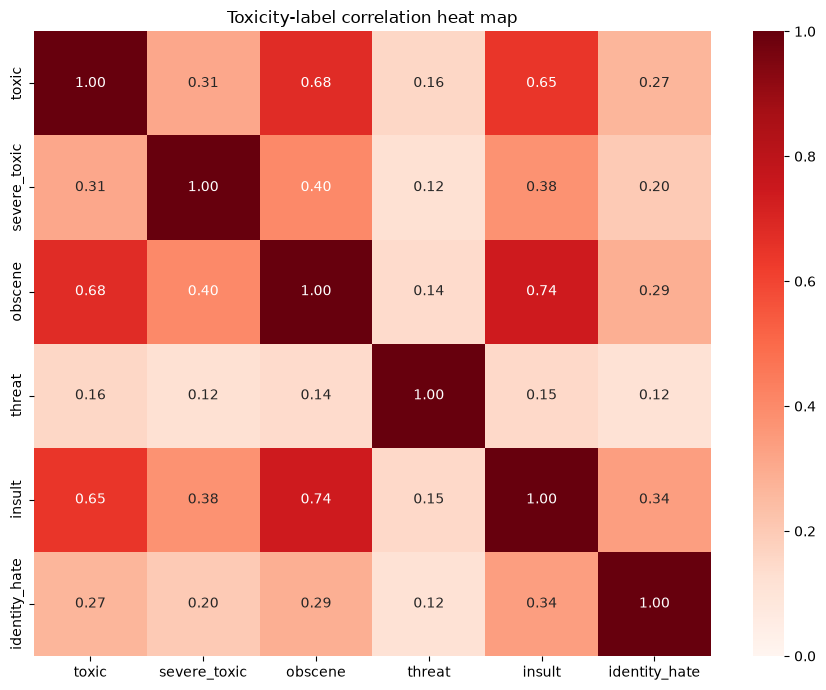

In [14]:
correlations = df[LABELS].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title('Toxicity-label correlation heat map')
plt.tight_layout()
plt.savefig(REPORTS_PATH / 'label_correlation_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

In [15]:
model_df = df
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    model_df = df.sample(SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

X = model_df['clean_comment'].astype(str)
y = model_df[LABELS].astype('float32')

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)

print(f'Rows selected: {len(model_df):,}')
print(f'Training rows: {len(X_train):,}')
print(f'Validation rows: {len(X_valid):,}')

Rows selected: 159,571
Training rows: 127,656
Validation rows: 31,915


## Build and adapt the text vectorizer

The vectorizer learns its vocabulary only from the training partition, preventing validation-data leakage.

In [16]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH,
    name='text_vectorization',
)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(X_train.to_numpy()).batch(1024)
)

vocabulary = vectorizer.get_vocabulary()
print(f'Vocabulary size: {len(vocabulary):,}')
print('Example vocabulary:', vocabulary[2:22])
print('Vectorized example:', vectorizer(X_train.iloc[0])[:25].numpy())

Vocabulary size: 50,000
Example vocabulary: [np.str_('the'), np.str_('to'), np.str_('is'), np.str_('i'), np.str_('and'), np.str_('of'), np.str_('you'), np.str_('a'), np.str_('number'), np.str_('that'), np.str_('it'), np.str_('in'), np.str_('not'), np.str_('for'), np.str_('this'), np.str_('on'), np.str_('have'), np.str_('are'), np.str_('be'), np.str_('as')]
Vectorized example: [12214  7652    59  3731    13  4102 12214  7652     4  4102     5   379
 12214  7652   475   874   181     3   805    10    10    10    10     0
     0]


## Build the Bidirectional LSTM model

In [17]:
inputs = tf.keras.Input(shape=(), dtype=tf.string, name='comment')
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(
    input_dim=len(vocabulary),
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name='embedding',
)(x)

x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(LSTM_UNITS, dropout=0.2),
    name='bidirectional_lstm',
)(x)

x = tf.keras.layers.Dense(64, activation='relu', name='dense')(x)
x = tf.keras.layers.Dropout(0.4, name='dropout')(x)
outputs = tf.keras.layers.Dense(
    len(LABELS), activation='sigmoid', name='toxicity_probabilities'
)(x)


model = tf.keras.Model(inputs, outputs, name='toxic_comment_bilstm')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
        tf.keras.metrics.AUC(name='roc_auc', multi_label=True, num_labels=len(LABELS)),
    ],
)

model.summary()

Model: "toxic_comment_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ comment             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 200)       │          0 │ comment[0][0]     │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  6,400,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional_ls… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ toxicity_probabili… │ (None, 6)         │        390 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,507,462 (24.82 MB)

 Trainable params: 6,507,462 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=2, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_loss', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6
    ),
]

history = model.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    validation_data=(X_valid.to_numpy(), y_valid.to_numpy()),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 590s 588ms/step - binary_accuracy: 0.9758 - loss: 0.0807 - roc_auc: 0.9126 - val_binary_accuracy: 0.9821 - val_loss: 0.0479 - val_roc_auc: 0.9598 - learning_rate: 0.0010
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 465s 466ms/step - binary_accuracy: 0.9833 - loss: 0.0450 - roc_auc: 0.9668 - val_binary_accuracy: 0.9824 - val_loss: 0.0472 - val_roc_auc: 0.9611 - learning_rate: 0.0010
Epoch 3/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 486s 487ms/step - binary_accuracy: 0.9847 - loss: 0.0392 - roc_auc: 0.9762 - val_binary_accuracy: 0.9818 - val_loss: 0.0494 - val_roc_auc: 0.9628 - learning_rate: 0.0010
Epoch 4/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 471s 471ms/step - binary_accuracy: 0.9868 - loss: 0.0330 - roc_auc: 0.9846 - val_binary_accuracy: 0.9820 - val_loss: 0.0535 - val_roc_auc: 0.9570 - learning_rate: 5.0000e-04


## Plot training results

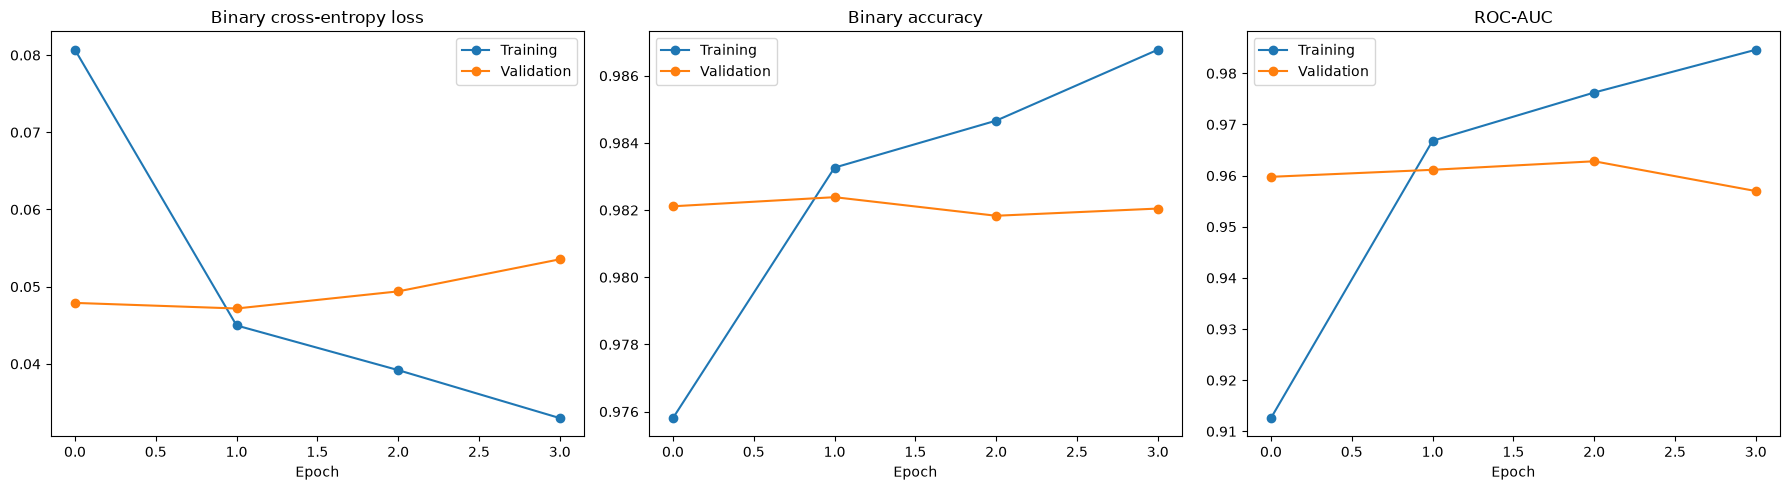

In [19]:
figure, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], marker='o', label='Training')
axes[0].plot(history.history['val_loss'], marker='o', label='Validation')
axes[0].set_title('Binary cross-entropy loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['binary_accuracy'], marker='o', label='Training')
axes[1].plot(history.history['val_binary_accuracy'], marker='o', label='Validation')
axes[1].set_title('Binary accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['roc_auc'], marker='o', label='Training')
axes[2].plot(history.history['val_roc_auc'], marker='o', label='Validation')
axes[2].set_title('ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

figure.tight_layout()
figure.savefig(REPORTS_PATH / 'lstm_training_history.png', dpi=160, bbox_inches='tight')
plt.show()

## Evaluate the model

In [20]:
probabilities = model.predict(X_valid.to_numpy(), batch_size=BATCH_SIZE)

threshold_records = []
label_thresholds = {}
for label_index, label in enumerate(LABELS):
    precision_curve, recall_curve, threshold_curve = precision_recall_curve(
        y_valid[label].to_numpy(), probabilities[:, label_index]
    )
    if len(threshold_curve) == 0:
        best_threshold = GLOBAL_THRESHOLD
        best_f1 = 0.0
    else:
        f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / (
            precision_curve[:-1] + recall_curve[:-1] + 1e-12
        )
        best_index = int(np.nanargmax(f1_curve))
        best_threshold = float(threshold_curve[best_index])
        best_f1 = float(f1_curve[best_index])

    label_thresholds[label] = best_threshold
    threshold_records.append({
        'Label': label,
        'Calibrated threshold': best_threshold,
        'Best validation F1': best_f1,
        'Positive validation examples': int(y_valid[label].sum()),
    })

threshold_array = np.array([label_thresholds[label] for label in LABELS])
predictions = (probabilities >= threshold_array).astype('int32')

micro_f1 = f1_score(y_valid, predictions, average='micro', zero_division=0)
macro_f1 = f1_score(y_valid, predictions, average='macro', zero_division=0)
micro_auc = roc_auc_score(y_valid, probabilities, average='micro')
macro_auc = roc_auc_score(y_valid, probabilities, average='macro')

threshold_table = pd.DataFrame(threshold_records)
display(threshold_table.style.format({
    'Calibrated threshold': '{:.4f}',
    'Best validation F1': '{:.4f}',
}))
threshold_table.to_csv(REPORTS_PATH / 'label_thresholds.csv', index=False)
THRESHOLDS_PATH.write_text(json.dumps(label_thresholds, indent=2), encoding='utf-8')

print(f'Micro F1:      {micro_f1:.4f}')
print(f'Macro F1:      {macro_f1:.4f}')
print(f'Micro ROC-AUC: {micro_auc:.4f}')
print(f'Macro ROC-AUC: {macro_auc:.4f}')
print('\nDetailed classification report using calibrated per-label thresholds:\n')
print(classification_report(y_valid, predictions, target_names=LABELS, zero_division=0))


250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step


,Label,Calibrated threshold,Best validation F1,Positive validation examples
0,toxic,0.3898,0.8041,3056
1,severe_toxic,0.2564,0.5155,321
2,obscene,0.4488,0.8089,1715
3,threat,0.0576,0.1635,74
4,insult,0.2745,0.7300,1614
5,identity_hate,0.1642,0.2846,294


Micro F1:      0.7317
Macro F1:      0.5511
Micro ROC-AUC: 0.9871
Macro ROC-AUC: 0.9786

Detailed classification report using calibrated per-label thresholds:

               precision    recall  f1-score   support

        toxic       0.81      0.80      0.80      3056
 severe_toxic       0.44      0.62      0.52       321
      obscene       0.85      0.77      0.81      1715
       threat       0.11      0.35      0.16        74
       insult       0.66      0.81      0.73      1614
identity_hate       0.23      0.36      0.28       294

    micro avg       0.70      0.76      0.73      7074
    macro avg       0.52      0.62      0.55      7074
 weighted avg       0.74      0.76      0.75      7074
  samples avg       0.06      0.07      0.06      7074



In [21]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_valid, predictions, average=None, zero_division=0
)
result_table = pd.DataFrame({
    'Label': LABELS,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'Support': support,
})
display(result_table.style.format({
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-score': '{:.4f}'
}))
result_table.to_csv(REPORTS_PATH / 'per_label_results.csv', index=False)

,Label,Precision,Recall,F1-score,Support
0,toxic,0.8126,0.7958,0.8041,3056
1,severe_toxic,0.4412,0.6199,0.5155,321
2,obscene,0.8503,0.7714,0.8089,1715
3,threat,0.1066,0.3514,0.1635,74
4,insult,0.6633,0.8116,0.7300,1614
5,identity_hate,0.2336,0.3639,0.2846,294


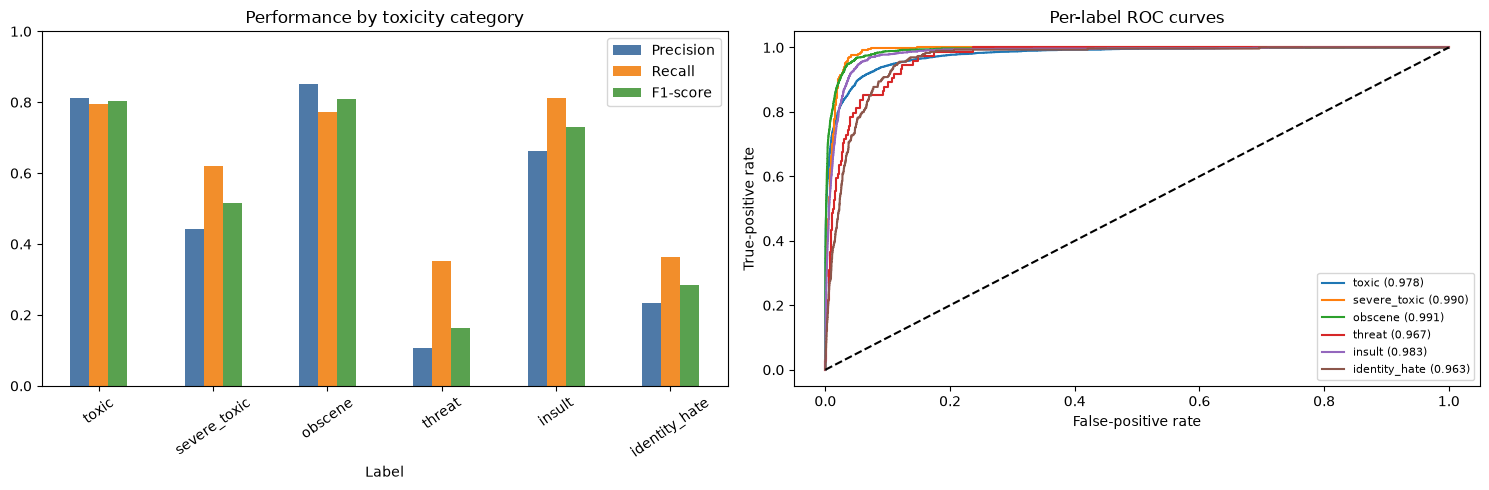

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))

result_table.set_index('Label')[['Precision', 'Recall', 'F1-score']].plot(
    kind='bar', ax=axes[0], color=['#4e79a7', '#f28e2b', '#59a14f']
)
axes[0].set_title('Performance by toxicity category')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=35)

for index, label in enumerate(LABELS):
    false_positive_rate, true_positive_rate, _ = roc_curve(y_valid[label], probabilities[:, index])
    label_auc = roc_auc_score(y_valid[label], probabilities[:, index])
    axes[1].plot(false_positive_rate, true_positive_rate, label=f'{label} ({label_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Per-label ROC curves')
axes[1].set_xlabel('False-positive rate')
axes[1].set_ylabel('True-positive rate')
axes[1].legend(fontsize=8)

figure.tight_layout()
figure.savefig(REPORTS_PATH / 'model_evaluation.png', dpi=160, bbox_inches='tight')
plt.show()

## Confusion matrices for all labels

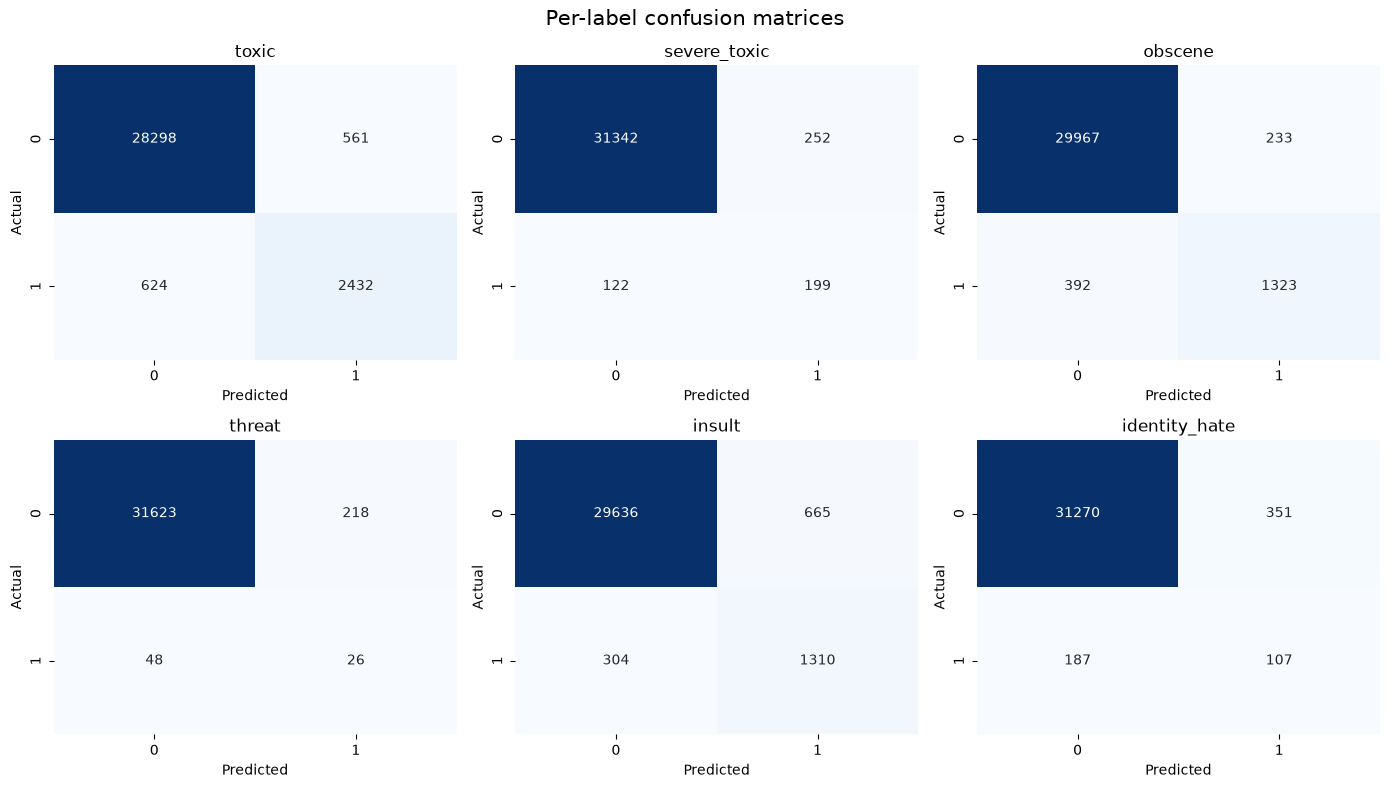

In [23]:
matrices = multilabel_confusion_matrix(y_valid, predictions)
figure, axes = plt.subplots(2, 3, figsize=(14, 8))

for label, matrix, axis in zip(LABELS, matrices, axes.flat):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(label)
    axis.set_xlabel('Predicted')
    axis.set_ylabel('Actual')

figure.suptitle('Per-label confusion matrices', fontsize=15)
figure.tight_layout()
figure.savefig(REPORTS_PATH / 'confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

## Save metrics and the complete trained model

In [24]:
metrics = {
    'rows_used': len(model_df),
    'training_rows': len(X_train),
    'validation_rows': len(X_valid),
    'global_threshold': GLOBAL_THRESHOLD,
    'label_thresholds': label_thresholds,
    'micro_f1': float(micro_f1),
    'macro_f1': float(macro_f1),
    'micro_roc_auc': float(micro_auc),
    'macro_roc_auc': float(macro_auc),
}

model.save(MODEL_PATH)
(REPORTS_PATH / 'lstm_metrics.json').write_text(
    json.dumps(metrics, indent=2), encoding='utf-8'
)

print(json.dumps(metrics, indent=2))
print('Model saved to:', MODEL_PATH.resolve())
print('Per-label thresholds saved to:', THRESHOLDS_PATH.resolve())


{
  "rows_used": 159571,
  "training_rows": 127656,
  "validation_rows": 31915,
  "global_threshold": 0.5,
  "label_thresholds": {
    "toxic": 0.38981619477272034,
    "severe_toxic": 0.2563701868057251,
    "obscene": 0.44878512620925903,
    "threat": 0.05764301121234894,
    "insult": 0.27453306317329407,
    "identity_hate": 0.164219930768013
  },
  "micro_f1": 0.731747000203376,
  "macro_f1": 0.5511126109772244,
  "micro_roc_auc": 0.9871274056746531,
  "macro_roc_auc": 0.9785758728652265
}
Model saved to: C:\Users\User\Desktop\IRFAN\Toxic Comment Classifier\models\toxic_bilstm.keras
Per-label thresholds saved to: C:\Users\User\Desktop\IRFAN\Toxic Comment Classifier\models\label_thresholds.json


## Predict custom comments

In [25]:
def predict_comment(comment, thresholds=None):
    if thresholds is None:
        thresholds = label_thresholds if 'label_thresholds' in globals() else {label: GLOBAL_THRESHOLD for label in LABELS}

    cleaned = clean_text(comment)
    scores = model.predict(np.asarray([cleaned], dtype=object), verbose=0)[0]
    threshold_values = np.array([thresholds.get(label, GLOBAL_THRESHOLD) for label in LABELS])

    result = pd.DataFrame({
        'Label': LABELS,
        'Probability': scores,
        'Threshold': threshold_values,
    })
    result['Detected'] = result['Probability'] >= result['Threshold']
    return result.sort_values('Probability', ascending=False).reset_index(drop=True)

display(predict_comment('You are stupid and I hate you.'))
display(predict_comment('Thank you for your thoughtful and helpful answer.'))


,Label,Probability,Threshold,Detected
0,toxic,0.985050,0.389816,True
1,obscene,0.691472,0.448785,True
2,insult,0.681129,0.274533,True
3,identity_hate,0.110209,0.164220,False
4,severe_toxic,0.061637,0.256370,False
5,threat,0.019329,0.057643,False


,Label,Probability,Threshold,Detected
0,toxic,1.487721e-03,0.389816,False
1,obscene,9.343880e-05,0.448785,False
2,insult,5.320983e-05,0.274533,False
3,identity_hate,2.942918e-05,0.164220,False
4,threat,4.457317e-06,0.057643,False
5,severe_toxic,5.682006e-07,0.256370,False


## Interactive dashboard



In [26]:
import ipywidgets as widgets

comment_input = widgets.Textarea(
    value='',
    placeholder='Type or paste a comment here...',
    description='Comment:',
    layout=widgets.Layout(width='90%', height='120px'),
    style={'description_width': '80px'},
)
use_calibrated_thresholds = widgets.Checkbox(
    value=True,
    description='Use calibrated per-label thresholds',
    indent=False,
)
fallback_threshold_input = widgets.FloatSlider(
    value=GLOBAL_THRESHOLD, min=0.05, max=0.90, step=0.05,
    description='Fallback:', continuous_update=False,
    style={'description_width': '80px'},
)
analyze_button = widgets.Button(
    description='Analyze comment', button_style='primary', icon='search'
)
dashboard_output = widgets.Output()

def current_dashboard_thresholds():
    if use_calibrated_thresholds.value and 'label_thresholds' in globals():
        return label_thresholds
    return {label: fallback_threshold_input.value for label in LABELS}

def analyze_comment(_):
    with dashboard_output:
        dashboard_output.clear_output(wait=True)
        if not comment_input.value.strip():
            print('Please enter a comment.')
            return

        thresholds = current_dashboard_thresholds()
        result = predict_comment(comment_input.value, thresholds=thresholds)
        detected = result.loc[result['Detected'], 'Label'].tolist()
        overall_score = result['Probability'].max()

        print(f'Overall toxicity score: {overall_score:.2%}')
        print('Detected categories:', ', '.join(detected) if detected else 'None')
        display(result.style.format({'Probability': '{:.2%}', 'Threshold': '{:.2%}'}))

        plt.figure(figsize=(9, 4))
        colors = ['#d1495b' if value else '#69b3a2' for value in result['Detected']]
        plt.barh(result['Label'], result['Probability'], color=colors)
        for _, row in result.iterrows():
            plt.scatter(row['Threshold'], row['Label'], color='black', marker='|', s=180)
        plt.xlim(0, 1)
        plt.xlabel('Probability')
        plt.title('Toxicity prediction with per-label threshold markers')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

analyze_button.on_click(analyze_comment)
display(widgets.VBox([
    widgets.HTML('<h3>Bidirectional LSTM Toxic Comment Dashboard</h3>'),
    widgets.HTML('<p>Rare labels use calibrated thresholds, so severe_toxic, threat, and identity_hate are not forced to pass the same 0.50 cutoff as common labels.</p>'),
    comment_input,
    use_calibrated_thresholds,
    fallback_threshold_input,
    analyze_button,
    dashboard_output,
]))
